# Power System Simulation Package

**Final Presentation – Power System Computation and Simulation**

Team: *Power_Flow*  
Members: *Christina Vaintirli, Christo Christozov, Emir Terzier, Mehmet Kizildenizli, Yigit Dilmen*

---

## Presentation Structure

1. Project overview  
2. Assignment 1 & 2  
3. EV analysis  
4. N-1 analysis  
5. Tap optimization  
6. Collaboration and conclusions


# 1. Project Overview

**Presenter:** *Yigit*

## Goal of the project

A python package for distribution-grid analysis. You give it a grid and load profiles, and it answers planning questions about voltages, losses, EVs, tap settings, and contingencies. 

The project has three aims:

- Build a Python package for power system analysis
- Apply real software engineering practices: Git, testing, documentation, packaging
- Demonstrate functionality on realistic grids.
  
## Package overview

The package is organized in **three layers**, one per assignment, each based on the one before it: 
- **Graph Layer** (Assignment 1), grid topology: connectivity, cycles. which houses sit on which feeder.
- **Power-Flow Layer** (Assignment 2), time-series power flow calculation and result aggregation into two tables: per timestep voltages and per-line loading/losses.
- **Analytics Layer** (Assignment 3), EV penetration, tap optimization, and N-1 contingency: Uses the previous two layers to reshape the input and read the tables back.

Everything is driven by one dataclass. `PowerSystemCase`, that bundles the grid, the load profiles, the EV pool and the feeder IDs. 
For every feature the following sequence repeats: **Build a case → validate → call one analysis → read two tables**

**Easy to use:** every analysis is a single function call on the same `case`
object — no reconfiguring, no re-loading. Learn the pattern once, and all five
features work the same way.

### Why this package?

Grid operators have to make real planning decisions and need quantitative answers, not guesses:

- **Will voltages stay safe?** Too many houses drawing power at once pushes voltages out of the legal band.
- **How much energy is wasted as heat in the wires?** That waste costs money.
- **Can the grid handle the future — e.g. everyone charging an EV?**
- **What's the best transformer setting to keep voltages healthy?**
- **If a wire fails, can we reroute power so nobody loses electricity?**

Answering these by hand is infeasible on a real grid with hundreds of houses and a full year of 15-minute data. This package automates it: feed in the grid and load profiles, get back quantitative answers to each question.

### Install & run

The project uses `uv` for dependency management.

```shell
git clone https://github.com/tue-ees-5xwg0/power-system-simulation-Power_Flow.git
cd power-system-simulation
uv sync                  # install dependencies + the package
uv run pytest            # run the test suite (61 tests, ~99% coverage)
```

Then any analysis follows the same pattern:

```python
from power_system_simulation import PowerSystemCase, run_ev_penetration_analysis

# Step 1: Pack all your individual inputs into one box, only needed once
case = PowerSystemCase(input_data, active_profile, reactive_profile, lv_feeder_ids, ev_profiles)

# Step 2: Check that this "box" holds valid data
validate_case(case)

# Step 3: Call the desired analysis: pass the "box" + the specific analysis's settings
voltage_summary, line_summary = run_ev_penetration_analysis(case, penetration_level=0.20, random_seed=42)
```

Code style and quality are enforced with `ruff` (linting + formatting), and CI
runs the full test suite on every push.

In [3]:
# Core libaries used throughout
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The package's public API — one case object, then one call per analysis
from power_system_simulation import (
    PowerSystemCase, 
    validate_case, 
    PowerFlowProcessor, 
    run_ev_penetration_analysis, 
    optimize_tap_position, 
    run_n_minus_one_analysis, 
)
from power_system_simulation.grid_graph import build_graph_processor

In [4]:
# Public API, grouped by layer 
print("Layer 1 - Graph:        build_graph_processor, GraphProcessor")
print("Layer 2 - Power flow:   PowerFlowProcessor (run_time_series, get_voltage_summary, get_line_summary)")
print("Layer 3 - Analytics:    run_ev_penetration_analysis, optimize_tap_position, run_n_minus_one_analysis")
print("Shared:                 PowerSystemCase, validate_case")


Layer 1 - Graph:        build_graph_processor, GraphProcessor
Layer 2 - Power flow:   PowerFlowProcessor (run_time_series, get_voltage_summary, get_line_summary)
Layer 3 - Analytics:    run_ev_penetration_analysis, optimize_tap_position, run_n_minus_one_analysis
Shared:                 PowerSystemCase, validate_case


# 2. Assignment 1 & 2

**Presenter:** *Christina*

These are the two foundation layers, everything in Assignment 3 is built directly on top of them. 

## Assignment 1: Graph processing

Forgetting about electricity, grids is just some dots connected by lines, otherwise known as a *graph*. This layer answers topology questions about the structure: 

- **Downstream vertex detection:** Given a wire, which houses sit below it, further away from the source? This is used to find which houses belong to which feeder.
  
- **Alternative edge detection:** Grids are built as loops but often run as a tree with some branches/wires being switched off. If a wire fails, which switched-off wires can be turned on to reconnect everyone?

- **Handling radial and meshed networks:** #maybe remove

### Design notes

**Adjacency list for storage.** The grid is stored as an adjacency list —
each vertex keeps a short list of its `(neighbour, edge_id)` pairs. Power grids
are *sparse* (a tree of V vertices has only V−1 edges, so each vertex touches
just a few others), so a list stores only the connections that actually exist
and lets us read a vertex's neighbours directly. Processing a vertex costs
O(degree(v)), and a full traversal is O(V + E) — which, since E = V − 1 for our
tree, is linear in the size of the grid. A dense V×V adjacency matrix would be
mostly empty and waste both memory and lookup time.

**One BFS at construction, reused everywhere.** We run a single
breadth-first search from the source when the object is built, and it does two
jobs at once:
- **Connectivity check** — a vertex ends up in `distance_from_source` *iff* it
  is reachable from the source. If the dictionary doesn't cover every vertex,
  the grid is disconnected (`GraphNotFullyConnectedError`).
- **Distance precomputation** — because BFS expands outward in rings, the ring a
  vertex lands in *is* its hop-distance from the source, which we store in
  `distance_from_source`.

That stored distance is what makes `find_downstream_vertices` trivial: the
downstream end of any edge is simply the endpoint with the **larger** distance —
an instant comparison instead of re-deriving direction each call. (BFS over DFS
specifically because BFS yields this distance for free; DFS does not.)

**Disabled edges are retained.** Open (disabled) lines stay in `edge_map`, so
`find_alternative_edges` can consider them as reconnection candidates without
rebuilding the graph.

**Cycle check by counting.** A valid spanning tree has exactly V−1 enabled
edges, so after the connectivity check we simply compare the enabled-edge count
to V−1 (`GraphCycleError` otherwise) — no extra traversal needed.

*The theme: do the expensive work once at construction (build the list, run one
BFS), then every later query just reads the precomputed result. This matters
because Assignment 3 calls these graph functions repeatedly.*

## Assignment 2: Power flow result processing

This is the physics engine. Given the grid and how much power each house draws
**at every timestep**, it runs a time-series power flow and aggregates the raw
output into two summary tables:

- **Node/voltage table** — per timestep, the highest and lowest voltage in the
  grid and which node they occurred at. (Are we in the safe voltage band?)
- **Line table** — per wire: its peak loading and when, plus total **energy loss**
  over the period, computed by integrating power loss over time (trapezoidal rule)
  and converting to kWh.

*These two tables are the output that every Assignment 3 analysis reads back.*


In [5]:
# Assignment 1 demo placeholder

# - Example graph
# - Run graph processing functions
# - Show result
# - We can do this live or pre-run/load it so we only show the results (second option safer)

In [6]:
# Assignment 2 demo placeholder

# - Load example power flow results
# - Run processing functions
# - Display summary DataFrame


# 3. EV Analysis

**Presenter:** *Emir*

## Problem Statement

In this section, we evaluate how electric vehicle charging affects the LV distribution grid.

We compare two cases:

- **Base case:** normal household load profiles
- **EV case:** additional EV charging profiles assigned to households

The goal is to quantify the effect of EV adoption on:

- node voltage levels
- line loading
- potential grid bottlenecks


## Methodology

The EV analysis follows the workflow below:

1. Load the network and time-series load profiles.
2. Group households by feeder using the network topology.
3. Assign EV charging demand to a selected percentage of households.
4. Run a time-series power flow simulation.
5. Compare the results against the original network.

This allows us to evaluate how increasing EV penetration affects the operational performance of the distribution grid.

In [6]:
# Directory/Data Setup

ROOT = Path.cwd()

if ROOT.name == "example":
    ROOT = ROOT.parent

INPUT_DIR = ROOT / "data" / "input" / "big_data"
OUTPUT_DIR = ROOT / "data" / "output" / "big_data"

# Input files
NETWORK_FILE = INPUT_DIR / "input_network_data_big.json"
ACTIVE_PROFILE_FILE = INPUT_DIR / "active_power_profile_big.parquet"
REACTIVE_PROFILE_FILE = INPUT_DIR / "reactive_power_profile_big.parquet"
META_FILE = INPUT_DIR / "meta_data_big.json"

# EV analysis output
EV_RESULTS_FILE = OUTPUT_DIR / "ev_analysis_results.csv"

# Load metadata
with META_FILE.open() as file:
    meta_data = json.load(file)

LV_FEEDER_IDS = meta_data["lv_feeders"]

print("LV feeders:", LV_FEEDER_IDS)

LV feeders: [1204, 1304, 1404, 1504, 1604, 1704, 1804, 1904]


In [7]:
# Load network and profiles
input_data = read_pgm_json(NETWORK_FILE)

active_power_profile = read_load_profile(
    ACTIVE_PROFILE_FILE
)

reactive_power_profile = read_load_profile(
    REACTIVE_PROFILE_FILE
)

# Create simulation case
case = PowerSystemCase(
    input_data=input_data,
    active_power_profile=active_power_profile,
    reactive_power_profile=reactive_power_profile,
    lv_feeder_ids=LV_FEEDER_IDS,
)

print("Network and load profiles loaded successfully.")

Network and load profiles loaded successfully.


In [33]:

EV_ACTIVE_PROFILE_FILE = INPUT_DIR / "ev_active_power_profile_big.parquet"

EV_VOLTAGE_RESULTS_FILE = OUTPUT_DIR / "ev_voltage_summary.csv"
EV_LINE_RESULTS_FILE = OUTPUT_DIR / "ev_line_summary.csv"

EV_PENETRATION_LEVEL = 0.5
RANDOM_SEED = 42
RUN_EV_ANALYSIS = False

BASE_VOLTAGE_RESULTS_FILE = OUTPUT_DIR / "base_voltage_summary.csv"
BASE_LINE_RESULTS_FILE = OUTPUT_DIR / "base_line_summary.csv"

RUN_BASE_CASE = False  # set to False after running once

if RUN_BASE_CASE:
    base_processor = PowerFlowProcessor(
        input_data,
        active_power_profile,
        reactive_power_profile,
    )
    base_processor.run_time_series()

    base_voltage_summary = base_processor.get_voltage_summary()
    base_line_summary = base_processor.get_line_summary()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    base_voltage_summary.to_csv(BASE_VOLTAGE_RESULTS_FILE)
    base_line_summary.to_csv(BASE_LINE_RESULTS_FILE)
else:
    base_voltage_summary = pd.read_csv(BASE_VOLTAGE_RESULTS_FILE, index_col=0, parse_dates=True)
    base_line_summary = pd.read_csv(BASE_LINE_RESULTS_FILE, index_col=0, parse_dates=True)

display(Markdown("## Base Case Voltage Summary"))
display(base_voltage_summary.head())

display(Markdown("## Base Case Line Loading Summary"))
display(base_line_summary.head())

ev_active_power_profiles = read_load_profile(EV_ACTIVE_PROFILE_FILE)

case = PowerSystemCase(
    input_data=input_data,
    active_power_profile=active_power_profile,
    reactive_power_profile=reactive_power_profile,
    lv_feeder_ids=LV_FEEDER_IDS,
    ev_active_power_profiles=ev_active_power_profiles,
)

if RUN_EV_ANALYSIS:
    ev_voltage_summary, ev_line_summary = run_ev_penetration_analysis(
        case,
        penetration_level=EV_PENETRATION_LEVEL,
        random_seed=RANDOM_SEED,
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    ev_voltage_summary.to_csv(EV_VOLTAGE_RESULTS_FILE)
    ev_line_summary.to_csv(EV_LINE_RESULTS_FILE)
else:
    ev_voltage_summary = pd.read_csv(EV_VOLTAGE_RESULTS_FILE, index_col=0, parse_dates=True)
    ev_line_summary = pd.read_csv(EV_LINE_RESULTS_FILE, index_col=0, parse_dates=True)

display(Markdown("## EV Voltage Summary"))
display(Markdown(
    "Results of the time-series power flow after EV charging demand has been added."
))
display(ev_voltage_summary.head())

display(Markdown("## EV Line Loading Summary"))
display(Markdown(
    "Line loading and energy loss results for the EV charging scenario."
))
display(ev_line_summary.head())

## Base Case Voltage Summary

,Max_Voltage,Max_Voltage_Node,Min_Voltage,Min_Voltage_Node
Timestamp,,,,
2025-01-01 00:00:00,1.074658,1,1.049898,0
2025-01-01 00:15:00,1.074532,1,1.049891,0
2025-01-01 00:30:00,1.074927,1,1.049916,0
2025-01-01 00:45:00,1.074601,1,1.049894,0
2025-01-01 01:00:00,1.074482,1,1.049885,0


## Base Case Line Loading Summary

,Total_Loss,Max_Loading,Max_Loading_Timestamp,Min_Loading,Min_Loading_Timestamp
Line_ID,,,,,
1204-01-01,53.619019,0.058248,2025-11-07 09:45:00,4.447163e-03,2025-10-08 12:45:00
1205-01-01,0.184181,0.005681,2025-04-07 10:30:00,4.082249e-07,2025-03-04 17:15:00
1206-01-01,54.899474,0.054426,2025-11-05 23:15:00,3.731235e-03,2025-10-08 12:45:00
1207-01-01,0.224576,0.004753,2025-05-29 02:30:00,4.118517e-07,2025-12-29 15:30:00
1208-01-01,50.536788,0.056481,2025-11-07 09:45:00,3.791173e-03,2025-10-08 12:45:00


## EV Voltage Summary

Results of the time-series power flow after EV charging demand has been added.

,Max_Voltage,Max_Voltage_Node,Min_Voltage,Min_Voltage_Node
Timestamp,,,,
2025-01-01 00:00:00,1.074658,1,1.049898,0
2025-01-01 00:15:00,1.074532,1,1.049891,0
2025-01-01 00:30:00,1.074927,1,1.049916,0
2025-01-01 00:45:00,1.074601,1,1.049894,0
2025-01-01 01:00:00,1.074324,1,1.049879,0


## EV Line Loading Summary

Line loading and energy loss results for the EV charging scenario.

,Total_Loss,Max_Loading,Max_Loading_Timestamp,Min_Loading,Min_Loading_Timestamp
Line_ID,,,,,
1204-01-01,60.786547,0.077088,2025-05-29 23:00:00,5.047238e-03,2025-08-14 22:30:00
1205-01-01,0.184262,0.005681,2025-04-07 10:30:00,4.078192e-07,2025-03-04 17:15:00
1206-01-01,62.413676,0.071027,2025-05-29 23:00:00,4.446383e-03,2025-08-13 09:15:00
1207-01-01,0.224677,0.004753,2025-05-29 02:30:00,4.116860e-07,2025-12-29 15:30:00
1208-01-01,57.622266,0.072885,2025-05-29 23:00:00,4.333970e-03,2025-08-13 09:15:00


In [13]:
ev_summary = pd.DataFrame(
    {
        "Case": ["EV case"],
        "Penetration Level": [f"{EV_PENETRATION_LEVEL:.0%}"],
        "Minimum Voltage [p.u.]": [ev_voltage_summary["Min_Voltage"].min()],
        "Timestamp of Minimum Voltage": [ev_voltage_summary["Min_Voltage"].idxmin()],
        "Maximum Line Loading": [ev_line_summary["Max_Loading"].max()],
        "Most Loaded Line ID": [ev_line_summary["Max_Loading"].idxmax()],
    }
)

display(Markdown("## EV Impact Summary"))
display(Markdown(
    f"Key performance indicators for the {EV_PENETRATION_LEVEL:.0%} EV penetration scenario."
))

display(ev_summary)

## EV Impact Summary

Key performance indicators for the 50% EV penetration scenario.

,Case,Penetration Level,Minimum Voltage [p.u.],Timestamp of Minimum Voltage,Maximum Line Loading,Most Loaded Line ID
0,EV case,50%,1.045219,2025-05-29 18:30:00,0.115479,1310-01-01


## Relative Impact of EV Integration

Comparison between the base case and the 50% EV penetration scenario.

,Metric,Base Case,EV Case,Relative Change [%]
0,Minimum Voltage,1.049605,1.045219,-0.417798
1,Maximum Line Loading,0.073235,0.115479,57.682198
2,Total Network Loss,7414.360240,8573.484777,15.633507


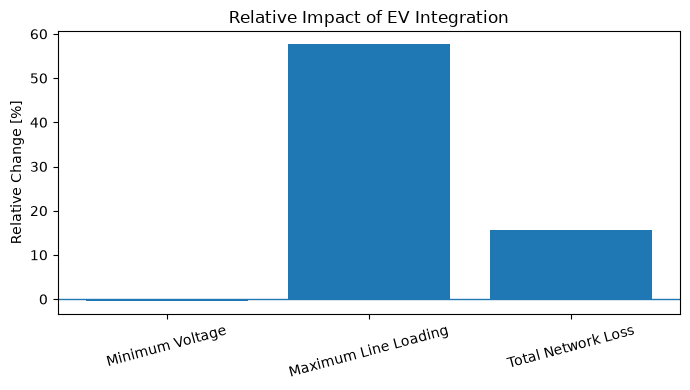

In [32]:
relative_impact = pd.DataFrame(
    {
        "Metric": [
            "Minimum Voltage",
            "Maximum Line Loading",
            "Total Network Loss",
        ],
        "Base Case": [
            base_voltage_summary["Min_Voltage"].min(),
            base_line_summary["Max_Loading"].max(),
            base_line_summary["Total_Loss"].sum(),
        ],
        "EV Case": [
            ev_voltage_summary["Min_Voltage"].min(),
            ev_line_summary["Max_Loading"].max(),
            ev_line_summary["Total_Loss"].sum(),
        ],
    }
)

relative_impact["Relative Change [%]"] = (
    (relative_impact["EV Case"] - relative_impact["Base Case"])
    / relative_impact["Base Case"]
    * 100
)

display(Markdown("## Relative Impact of EV Integration"))
display(Markdown(
    f"Comparison between the base case and the {EV_PENETRATION_LEVEL:.0%} EV penetration scenario."
))

display(relative_impact)

plt.figure(figsize=(7, 4))

plt.bar(
    relative_impact["Metric"],
    relative_impact["Relative Change [%]"],
)

plt.axhline(0, linewidth=1)

plt.ylabel("Relative Change [%]")
plt.title("Relative Impact of EV Integration")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

# 4. N-1 Analysis

**Presenter:** *Mehmet*

## Goal

Explain the purpose of N-1 analysis:

- Remove one network component at a time
- Re-run power flow
- Identify critical contingencies

## Key results

Show:

- Most critical outage
- Resulting overloads or voltage violations
- Interpretation of network robustness


In [9]:
# N-1 analysis demo
import json
from pathlib import Path
from power_system_simulation.contingency_analysis import run_n_minus_one_analysis
from power_grid_model import ComponentType
from power_grid_model.utils import json_deserialize_from_file

DATA_DIR = Path("../../Downloads/Input_Data_for_Demo")    # path to test file
#DATA_DIR = Path("../../Downloads/input")    # path to test file

input_data = json_deserialize_from_file(DATA_DIR / "input_network_data.json")
active_power_profile   = pd.read_parquet(DATA_DIR / "active_power_profile.parquet")
reactive_power_profile = pd.read_parquet(DATA_DIR / "reactive_power_profile.parquet")
ev_pool                = pd.read_parquet(DATA_DIR / "ev_active_power_profile.parquet")
meta_data = json.loads((DATA_DIR / "meta_data.json").read_text())
lv_feeder_ids = meta_data["lv_feeders"]   # 

case = PowerSystemCase(
    input_data=input_data,
    active_power_profile=active_power_profile,
    reactive_power_profile=reactive_power_profile,
    lv_feeder_ids=meta_data["lv_feeders"],
)

# line to take out of service
LINE_TO_TEST = meta_data["lv_feeders"][0]

n1_results = run_n_minus_one_analysis(case, disconnected_line_id=LINE_TO_TEST)
print(f"Line {LINE_TO_TEST} out of service: {len(n1_results)} alternative(s) found")
n1_results

Line 1204 out of service: 1 alternative(s) found


,Alternative_Line_ID,Max_Loading,Max_Loading_Line_ID,Max_Loading_Timestamp
0,2004,0.129424,1310,2025-11-05 02:00:00


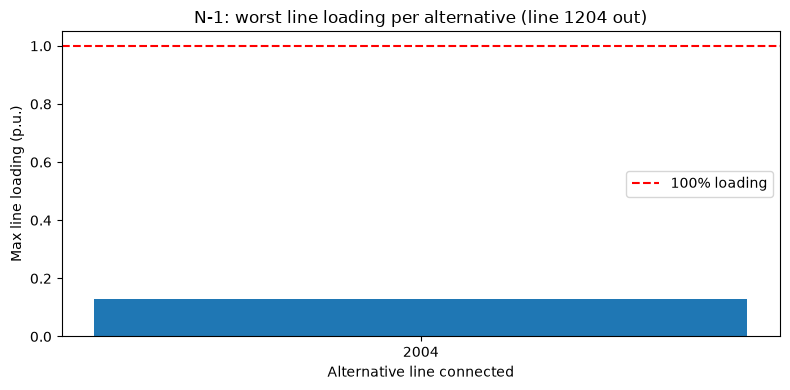

In [10]:
# N-1 analysis visualization

if n1_results.empty:
    print(f"No alternative lines can restore the grid when line {LINE_TO_TEST} is out of service.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(n1_results["Alternative_Line_ID"].astype(str), n1_results["Max_Loading"])
    ax.axhline(1.0, color="red", linestyle="--", label="100% loading")
    ax.set_xlabel("Alternative line connected")
    ax.set_ylabel("Max line loading (p.u.)")
    ax.set_title(f"N-1: worst line loading per alternative (line {LINE_TO_TEST} out)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 5. Tap Optimization

**Presenter:** *Christo*  

## Goal of this section

Transformer tap changers can shift the voltage level of the LV network.

In this part, we demonstrate a small optimization workflow:

> **Problem:** different transformer tap positions lead to different voltage profiles and losses.  
> **Method:** evaluate every available tap position by running a time-series power flow.  
> **Result:** select the tap position with the best objective value.

Disclaimer: For the live presentation, the calculation was **pre-run** on the big dataset due to time restrictions.


## Optimization Method

The implementation evaluates every tap position available in the transformer data.

For each candidate tap position:

1. Copy the original grid input data
2. Set the transformer tap position
3. Run a time-series power flow
4. Calculate the selected objective
5. Mark the best tap position as optimal

The function supports two criteria:

- `loss`: minimize total line energy loss
- `voltage_deviation`: minimize average voltage deviation from 1.0 p.u.


## Dataset characteristics

For tap optimization we use the **big Assignment 3 dataset**, because it contains the transformer and tap settings required for this module.

Relevant case information:

- MV source node: `0`
- LV busbar: `1`
- Transformer ID: `803`
- Initial tap position: `3`
- Available tap positions: `1` to `5`
- LV feeders: `1204, 1304, 1404, 1504, 1604, 1704, 1804, 1904`

The tap optimization itself only changes the transformer tap position; the rest of the network and the household load profiles remain unchanged.


In [11]:
# File paths
ROOT = Path.cwd().parent
INPUT_DIR = ROOT / "data" / "input" / "big_data"
OUTPUT_DIR = ROOT / "data" / "output" / "big_data"

NETWORK_FILE = INPUT_DIR / "input_network_data_big.json"
ACTIVE_PROFILE_FILE = INPUT_DIR / "active_power_profile_big.parquet"
REACTIVE_PROFILE_FILE = INPUT_DIR / "reactive_power_profile_big.parquet"
META_FILE = INPUT_DIR / "meta_data_big.json"

RESULT_FILE = OUTPUT_DIR / "tap_optimization_results.csv"

# From meta_data_big.json
with META_FILE.open() as file:
    meta_data = json.load(file)

LV_FEEDER_IDS = meta_data["lv_feeders"]

In [12]:
for file in [NETWORK_FILE, ACTIVE_PROFILE_FILE, REACTIVE_PROFILE_FILE, META_FILE]:
    print(f"{file.name}: {'✓ Found' if file.exists() else '✗ Missing'}")

input_network_data_big.json: ✓ Found
active_power_profile_big.parquet: ✓ Found
reactive_power_profile_big.parquet: ✓ Found
meta_data_big.json: ✓ Found


In [13]:
input_data = read_pgm_json(NETWORK_FILE)
active_power_profile = read_load_profile(ACTIVE_PROFILE_FILE)
reactive_power_profile = read_load_profile(REACTIVE_PROFILE_FILE)

In [14]:
with META_FILE.open() as file:
    meta_data = json.load(file)

case = PowerSystemCase(
    input_data=input_data,
    active_power_profile=active_power_profile,
    reactive_power_profile=reactive_power_profile,
    lv_feeder_ids=meta_data["lv_feeders"],
)

transformer = input_data[ComponentType.transformer][0]

print("Transformer ID:", int(transformer["id"]))
print("Initial tap position:", int(transformer["tap_pos"]))
print("Available tap range:", int(transformer["tap_max"]), "to", int(transformer["tap_min"]))

Transformer ID: 803
Initial tap position: 3
Available tap range: 1 to 5


In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tap_results_voltage = optimize_tap_position(case, criterion="voltage_deviation")
tap_results_voltage.to_csv(OUTPUT_DIR / "tap_optimization_voltage_deviation.csv", index=False)

tap_results_loss = optimize_tap_position(case, criterion="loss")
tap_results_loss.to_csv(OUTPUT_DIR / "tap_optimization_loss.csv", index=False)

In [16]:
display(Markdown("## Voltage Deviation Optimization"))
display(tap_results_voltage)

display(Markdown("## Loss Optimization"))
display(tap_results_loss)

## Voltage Deviation Optimization

,Tap_Position,Total_Loss,Voltage_Deviation,Is_Optimal
0,1,8133.664185,0.018734,True
1,2,7769.573159,0.042325,False
2,3,7414.360240,0.067000,False
3,4,7067.977189,0.092837,False
4,5,6730.377710,0.119921,False


## Loss Optimization

,Tap_Position,Total_Loss,Voltage_Deviation,Is_Optimal
0,1,8133.664185,0.018734,False
1,2,7769.573159,0.042325,False
2,3,7414.360240,0.067000,False
3,4,7067.977189,0.092837,False
4,5,6730.377710,0.119921,True


In [17]:
initial_tap = int(transformer["tap_pos"])

voltage_optimal_tap = int(
    tap_results_voltage.loc[tap_results_voltage["Is_Optimal"], "Tap_Position"].iloc[0]
)

loss_optimal_tap = int(
    tap_results_loss.loc[tap_results_loss["Is_Optimal"], "Tap_Position"].iloc[0]
)

comparison = pd.DataFrame(
    {
        "Case": ["Before optimization", "After voltage optimization", "After loss optimization"],
        "Tap_Position": [initial_tap, voltage_optimal_tap, loss_optimal_tap],
    }
)

display(Markdown("## Taps: Before and After"))
display(comparison)

## Taps: Before and After

,Case,Tap_Position
0,Before optimization,3
1,After voltage optimization,1
2,After loss optimization,5


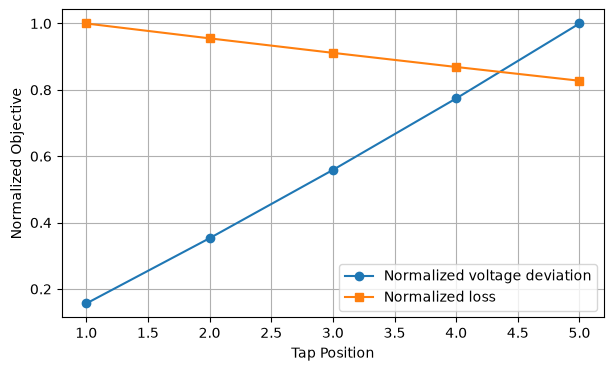

In [18]:
plot_data = tap_results_voltage.copy()

plot_data["Normalized_Loss"] = (
    tap_results_loss["Total_Loss"] / tap_results_loss["Total_Loss"].max()
)

plot_data["Normalized_Voltage_Deviation"] = (
    tap_results_voltage["Voltage_Deviation"]
    / tap_results_voltage["Voltage_Deviation"].max()
)

plt.figure(figsize=(7, 4))

plt.plot(
    plot_data["Tap_Position"],
    plot_data["Normalized_Voltage_Deviation"],
    marker="o",
    label="Normalized voltage deviation",
)

plt.plot(
    plot_data["Tap_Position"],
    plot_data["Normalized_Loss"],
    marker="s",
    label="Normalized loss",
)

plt.xlabel("Tap Position")
plt.ylabel("Normalized Objective")
plt.grid(True)
plt.legend()
plt.show()

## Tap Optimization Conclusion
- The optimal tap position depends on the selected optimization objective.
- **Voltage deviation optimization** selected **tap position 1**, resulting in the best overall voltage profile.
- **Loss optimization** selected **tap position 5**, resulting in the lowest network losses.
- The results highlight a trade-off between voltage quality and system losses.
- The implemented framework allows operators to automatically determine the tap position that best matches their operational priorities.



# 6. Collaboration and Conclusions

## Collaboration

Briefly go over:

- Git workflow
- Feature branches
- Pull requests
- Code reviews
- Testing and coverage 
- Division of work

## AI usage

Briefly explain AI tool usage + usefulness:

- As a learning tool
- Debugging
- Test writing
- Documentation
- Presentation preparation

Also mention that all generated output was reviewed and verified by the team.

## Final conclusion

Summarize the project:

- We built a working Python package
- We implemented graph and power flow computation functionality
- We applied it to practical grid analysis scenarios
- We worked using professional software engineering practices


In [19]:
# Maybe - show test coverage / quality checks

# run before presentation and save output
# !uv run pytest
# !uv run ruff check


# Backup / Extra Material

Use as an Appendix for the Q&A session.
Probably include our unit tests here in case they ask about them.
